# Basyor

# Creating an virtual environment  
1. ``conda create -n baysor``
2. ``conda activate baysor``
3. ``mamba install scanpy python-igraph leidenalg ipykernel spatialdata-io spatialdata-plot``
4. ``pip install numpy==1.26.4``
5. ``wget https://github.com/kharchenkolab/Baysor/releases/download/v0.7.1/baysor-x86_x64-linux-v0.7.1_build.zip``  
6. ``unzip baysor-x86_x64-linux-v0.7.1_build.zip`` or 
``python3 -m zipfile -e baysor-x86_x64-linux-v0.7.1_build.zip .``
7. ``conda deactivate baysor``
8. ``conda create -n baysor-spatial``
9. ``conda activate baysor-spatial``
10. ``mamba install python=3.10 scanpy python-igraph=0.9.9 leidenalg ipykernel spatialdata-io spatialdata-plot``

In [ ]:
import os
# Baysor 실행 파일이 위치한 경로를 PATH 앞쪽에 추가
os.environ["PATH"] = "./bin/baysor/bin:" + os.environ["PATH"]

In [ ]:
# cd ./bin/baysor/bin
# ll
# chmod u+x ./baysor

In [2]:
!baysor --help



  baysor v0.7.1



Usage

  baysor <command>

Commands

  preview                                                   Plot an html with the dataset preview.

  run                                                       Run cell segmentation

  segfree                                                   Extract Neighborhood Composition Vectors (NCVs) from a
                                                            dataset



Flags

  -h, --help                                                Print this help message.
  --version                                                 Print version.


In [4]:
import pandas as pd

def filter_transcripts(transcript,
                       min_qv=20.0,
                       min_x=3000.0,
                       max_x=4000.0,
                       min_y=4500.0,
                       max_y=5500.0):
    """
    주어진 transcripts CSV 파일을 읽어서 조건에 맞게 필터링한 후, 
    결과를 CSV 파일로 저장합니다.
    
    Parameters:y
        transcript (str): 입력 CSV 파일 경로.
        min_qv (float): 최소 Q-Score. (default: 20.0)
        min_x (float): 최소 x좌표. (default: 0.0)
        max_x (float): 최대 x좌표. (default: 24000.0)
        min_y (float): 최소 y좌표. (default: 0.0)
        max_y (float): 최대 y좌표. (default: 24000.0)
    """
    # CSV 파일 읽기
    data_frame = pd.read_csv(transcript)
    
    # 조건에 따라 필터링 (음성 대조군 제외)
    filtered_frame = data_frame[
        (data_frame["qv"] >= min_qv) &
        (data_frame["x_location"] >= min_x) &
        (data_frame["x_location"] <= max_x) &
        (data_frame["y_location"] >= min_y) &
        (data_frame["y_location"] <= max_y) &
        (~data_frame["feature_name"].str.startswith("NegControlProbe_")) &
        (~data_frame["feature_name"].str.startswith("antisense_")) &
        (~data_frame["feature_name"].str.startswith("NegControlCodeword_")) &
        (~data_frame["feature_name"].str.startswith("BLANK_"))
    ]
    
    # cell_id가 -1인 경우 0으로 변경
    neg_cell_row = filtered_frame["cell_id"] == -1
    filtered_frame.loc[neg_cell_row, "cell_id"] = 0
    
    # 출력 파일 이름 생성 및 CSV 저장
    output_filename = f"X{min_x}-{max_x}_Y{min_y}-{max_y}_filtered_transcripts.csv"
    filtered_frame.to_csv(output_filename, index=False, encoding='utf-8')
    print(f"필터링된 결과가 {output_filename} 파일에 저장되었습니다.")

# --------------------------------------------------------------------

def run_filter_example():
    """
    Example run function to demonstrate usage.
    Example:
        run_filter_example()  # transcripts.csv 파일이 현재 디렉토리에 있다고 가정.
    """
    # 파일 경로 및 필터 파라미터 설정
    transcript_file = "./transcripts.csv.gz"  # 여기에 실제 파일 경로를 입력하세요.
    min_qv = 20.0
    min_x = 3000.0
    max_x = 4000.0
    min_y = 4500.0
    max_y = 5500.0
    
    # 필터 함수 실행
    filter_transcripts(transcript_file, min_qv, min_x, max_x, min_y, max_y)

# --------------------------------------------------------------------

run_filter_example()

필터링된 결과가 X3000.0-4000.0_Y4500.0-5500.0_filtered_transcripts.csv 파일에 저장되었습니다.


In [3]:
!wget https://public.pnucolab.com/spatial-omics-tutorials/X3000.0-4000.0_Y4500.0-5500.0_filtered_transcripts.csv

--2025-07-25 06:44:10--  https://public.pnucolab.com/spatial-omics-tutorials/X3000.0-4000.0_Y4500.0-5500.0_filtered_transcripts.csv
Resolving public.pnucolab.com (public.pnucolab.com)... 164.125.255.244
Connecting to public.pnucolab.com (public.pnucolab.com)|164.125.255.244|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71910298 (69M) [text/csv]
Saving to: ‘X3000.0-4000.0_Y4500.0-5500.0_filtered_transcripts.csv’

X3000.0-4000.0_Y450 100%[===================>]  68.58M   107MB/s    in 0.6s    

2025-07-25 06:44:10 (107 MB/s) - ‘X3000.0-4000.0_Y4500.0-5500.0_filtered_transcripts.csv’ saved [71910298/71910298]



In [6]:
import pandas as pd
filtered_transcripts_csv = './X3000.0-4000.0_Y4500.0-5500.0_filtered_transcripts.csv'

pd.read_csv(filtered_transcripts_csv).head()

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,fov_name,nucleus_distance,codeword_index
0,281809984165310,hjjedkph-1,1,HLA-DRA,3000.6638,4589.9030,20.367735,24.831318,Y7,0.000000,424
1,281809984165318,hihafhcl-1,0,SPDEF,3002.2664,4713.3125,21.332820,40.000000,Y7,4.612793,234
2,281809984165323,hjjedkph-1,1,HLA-DRA,3003.0269,4591.7380,17.572792,40.000000,Y7,0.000000,424
3,281809984165329,hjjedkph-1,1,HLA-DRA,3003.5881,4593.4450,18.277754,24.831318,Y7,0.000000,424
4,281809984165338,UNASSIGNED,0,LRATD1,3005.6504,4664.2275,17.218480,40.000000,Y7,20.993397,434


In [7]:
# baysor preview [transcripts.csv] -x [name of x column] -y [name of y column] -z [name of z column] -g [name of gene column] -m [min molescules per cell]
!baysor preview {filtered_transcripts_csv} -x x_location -y y_location -z z_location -g feature_name -m 15

[06:46:18] Info: # CLI params: `./X3000.0-4000.0_Y4500.0-5500.0_filtered_transcripts.csv -x x_location -y y_location -z z_location -g feature_name -m 15`
[06:46:18] Info: (2025-07-25) Run Baysor v0.7.1
[06:46:18] Info: Loading data...
[06:46:24] Info: Loaded 843219 transcripts, 439 genes.
[06:46:25] Info: Estimating noise level
[06:46:40] Info: Done
[06:46:40] Info: Estimating local colors
[06:48:00] Info: Building transcript plots
[06:48:02] Info: Building gene structure plot
[06:48:27] Info: Plotting
[06:48:52] Info: All done!

(process:2392461): GLib-CRITICAL **: 06:48:52.389: g_datalist_id_set_data_full: assertion 'key_id > 0' failed

(process:2392461): GLib-CRITICAL **: 06:48:52.389: g_datalist_id_set_data_full: assertion 'key_id > 0' failed


In [8]:
# baysor run [transcripts.csv] -x [name of x column] -y [name of y column] -z [name of z column] -g [name of gene column] -m [min molescules per cell] [prior segmentation] --prior-segmentation-confidence 0.5 :cell_id
!baysor run {filtered_transcripts_csv} -x x_location -y y_location -z z_location -g feature_name -m 15 :cell_id --prior-segmentation-confidence 0.5 

[06:51:10] Info: Run Rb57179d5a
[06:51:10] Info: (2025-07-25) Run Baysor v0.7.1
[06:51:10] Info: Loading data...
[06:51:16] Info: Loaded 843219 transcripts, 439 genes.
[06:51:18] Warning: No unassigned molecules found in the prior segmentation. Did you specify the unassigned value correctly (0)? Most present assigned value: UNASSIGNED (246304 molecules).
└ Baysor.DataLoading /home/viktor_petukhov/.julia/dev/Baysor/src/data_loading/cli_wrappers.jl:22
[06:51:18] Info: Estimating noise level
[06:51:30] Info: Done
[06:51:43] Info: Clustering molecules...
Progress:   0%|                                         |  ETA: 0:54:27
  Iteration:                  2
  Max. difference:            0.766
4m  Fraction of probs changed:  1.0


Progress:   0%|                                         |  ETA: 0:57:59
  Iteration:                  5
  Max. difference:            0.584
4m  Fraction of probs changed:  1.0


Progress:   0%|                                         |  ETA: 0:53:20
  Iteration:   

In [9]:
pd.read_csv('segmentation.csv').head()

,transcript_id,cell_id,overlaps_nucleus,gene,x,y,z,qv,fov_name,nucleus_distance,codeword_index,molecule_id,prior_segmentation,confidence,cluster,cell,assignment_confidence,is_noise,ncv_color
0,281809984165310,hjjedkph-1,1,HLA-DRA,3000.6638,4589.9030,20.367735,24.831318,Y7,0.000000,424,1,6089,0.99980,1,CRb57179d5a-70,0.98,False,#3335C4
1,281809984165318,hihafhcl-1,0,SPDEF,3002.2664,4713.3125,21.332820,40.000000,Y7,4.612793,234,2,5024,0.99986,3,CRb57179d5a-473,1.00,False,#00E8FF
2,281809984165323,hjjedkph-1,1,HLA-DRA,3003.0269,4591.7380,17.572792,40.000000,Y7,0.000000,424,3,6089,0.99728,1,CRb57179d5a-70,1.00,False,#002A9E
3,281809984165329,hjjedkph-1,1,HLA-DRA,3003.5881,4593.4450,18.277754,24.831318,Y7,0.000000,424,4,6089,0.99865,1,CRb57179d5a-70,1.00,False,#002CA2
4,281809984165338,UNASSIGNED,0,LRATD1,3005.6504,4664.2275,17.218480,40.000000,Y7,20.993397,434,5,1,0.44968,3,CRb57179d5a-241,1.00,False,#00D8FF


In [10]:
pd.read_csv('segmentation_cell_stats.csv').head()

,cell,x,y,z,cluster,n_transcripts,density,elongation,area,avg_confidence,avg_assignment_confidence,max_cluster_frac,lifespan
0,CRb57179d5a-1,3001.661071,4500.677986,22.789265,3,7,2.0980,4.407,3.3360,0.7923,1.0,1.000000,50
1,CRb57179d5a-2,3003.996167,4507.558283,18.980074,3,6,1.2540,10.110,4.7850,0.6841,1.0,0.833333,50
2,CRb57179d5a-3,3006.314014,4502.744005,21.110086,3,22,0.5075,5.437,43.3500,0.6886,1.0,0.954545,50
3,CRb57179d5a-4,3002.427280,4517.820480,21.160224,3,5,1.9590,6.375,2.5520,0.5895,1.0,0.600000,50
4,CRb57179d5a-5,3010.020300,4514.682883,20.155191,3,6,16.1600,8.003,0.3714,0.2500,1.0,1.000000,50


### Converting Baysor outputs to Anndata
Transform segmentation.csv to barocdes.tsv.gz, features.tsv.gz, matrix.mtx.gz

In [11]:
import os
import sys
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import scipy.io as sio
import csv
import subprocess


baysor_file = "./segmentation.csv"  # Path to the segmentation CSV file
output_folder = "baysor_mtx"        # Name of the output folder
conf_cutoff = 0.9                   # assignment_confidence 
rep_int = 100000                    


if not os.path.exists(baysor_file):
    print(f"The specified Baysor file ({baysor_file}) does not exist!")
    raise FileNotFoundError(f"Baysor file {baysor_file} not found.")

if os.path.exists(output_folder):
    print(f"The specified output folder ({output_folder}) already exists!")
    raise FileExistsError(f"Output folder {output_folder} already exists.")


transcripts_df = pd.read_csv(baysor_file, usecols=["gene", "cell", "assignment_confidence"])

# 고유 유전자와 셀 목록 추출
features = np.unique(transcripts_df["gene"])
feature_to_index = {str(val): index for index, val in enumerate(features)}
cells = np.unique(transcripts_df["cell"].astype(str))
cells = cells[cells != "0"] # cell "0"은 제외 (0은 Baysor에서 unassigned을 의미)

# shape: [#gene, #cell] 형태로 0으로 빈 초기화
matrix = pd.DataFrame(0, index=range(len(features)), columns=cells, dtype=np.int32)

# 반복문으로 gene-cell matrix 채우기
for idx, row in transcripts_df.iterrows():
    if idx % rep_int == 0:
        print(f"{idx} transcripts processed.")
    feature = str(row['gene'])
    cell = str(row['cell']) 
    conf = row['assignment_confidence']
    
    if conf < conf_cutoff: # assignment_confidence < 0.9이면 skip
        continue
    
    if cell != "0":
        matrix.at[feature_to_index[feature], cell] += 1 # gene-cell 매트릭스에서 해당 위치 값 1 증가

matrix = matrix.T # 최종 matrix는 [cell × gene] 형태가 되도록 전치


def write_sparse_mtx(matrix, cell_names, gene_names, output_folder):
   
    os.mkdir(output_folder)
    
    sparse_mat = sparse.coo_matrix(matrix.values)
    
    sio.mmwrite(os.path.join(output_folder, "matrix.mtx"), sparse_mat)
    
    with open(os.path.join(output_folder, "barcodes.tsv"), 'w', newline='') as tsvfile: # 각 셀의 이름 저장 (cell_XXX)
        writer = csv.writer(tsvfile, delimiter='\t', lineterminator='\n')
        for cell in cell_names:
            writer.writerow([f"cell_{cell}"])
    
    # Write genes as features.tsv with three columns.
    with open(os.path.join(output_folder, "features.tsv"), 'w', newline='') as tsvfile: #  각 유전자의 정보
        writer = csv.writer(tsvfile, delimiter='\t', lineterminator='\n')
        for gene in gene_names:
            gene_str = str(gene)
            # NegControlProbe_, NegControlCodeword_, BLANK_ → Control로 분류
            if gene_str.startswith("NegControlProbe_") or gene_str.startswith("antisense_"):
                writer.writerow([gene_str, gene_str, "Negative Control Probe"])
            elif gene_str.startswith("NegControlCodeword_"):
                writer.writerow([gene_str, gene_str, "Negative Control Codeword"])
            elif gene_str.startswith("BLANK_"):
                writer.writerow([gene_str, gene_str, "Blank Codeword"])
            else: # 나머지는 "Gene Expression"으로 분류
                writer.writerow([gene_str, gene_str, "Gene Expression"])
    
    subprocess.run("gzip -f " + os.path.join(output_folder, "*"), shell=True) # gzip로 전부 압축
    print("Output files written and gzipped.")

# Call the helper function to write the MTX and associated files.
write_sparse_mtx(matrix, matrix.index, features, output_folder)

0 transcripts processed.
100000 transcripts processed.
200000 transcripts processed.
300000 transcripts processed.
400000 transcripts processed.
500000 transcripts processed.
600000 transcripts processed.
700000 transcripts processed.
800000 transcripts processed.
Output files written and gzipped.


Transform barocdes.tsv.gz, features.tsv.gz, matrix.mtx.gz to Anndata

In [12]:
import scanpy as sc
import anndata as ad
import pandas as pd


mat = sc.read_mtx("baysor_mtx/matrix.mtx.gz")

barcodes = pd.read_csv("baysor_mtx/barcodes.tsv.gz", header=None, sep='\t', compression='gzip')
cell_names = barcodes[0].values

features = pd.read_csv("baysor_mtx/features.tsv.gz", header=None, sep='\t', compression='gzip')
gene_names = features[0].values


adata = ad.AnnData(X=mat.X)
adata.obs_names = cell_names  
adata.var_names = gene_names  

if features.shape[1] >= 3:
    adata.var['feature_type'] = features[2].values

print(adata)

AnnData object with n_obs × n_vars = 16636 × 439
    var: 'feature_type'


In [13]:
# filter "UnassignedCodeword" 

print(len(adata.var))

mask = ~adata.var_names.str.startswith("UnassignedCodeword")
adata = adata[:, mask]

print(len(adata.var))

439
422


In [14]:
# AnnData 객체의 var_names (유전자 이름들)이 중복될 경우, 고유하게 만들어주는 함수
adata.var_names_make_unique()

In [15]:
adata

AnnData object with n_obs × n_vars = 16636 × 422
    var: 'feature_type'

In [16]:
adata.write_h5ad('./adata.h5ad')

## Analyzing Anndata using Scanpy

/home/l202255179/micromamba/envs/baysor/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


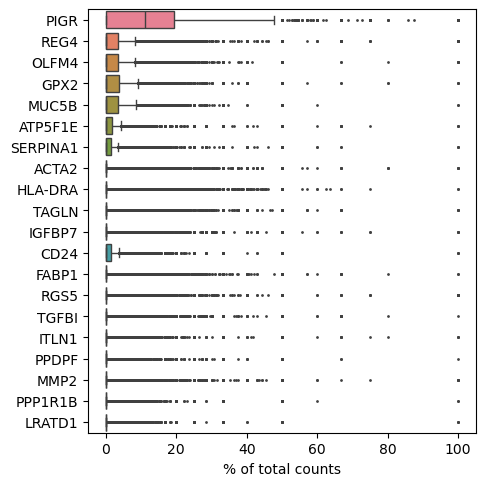

In [17]:
adata.X = adata.X.toarray()

sc.pl.highest_expr_genes(adata, n_top=20)

QC

In [18]:
sc.pp.calculate_qc_metrics(
    adata, percent_top=None, log1p=False, inplace=True
)

In [19]:
adata

AnnData object with n_obs × n_vars = 16636 × 422
    obs: 'n_genes_by_counts', 'total_counts'
    var: 'feature_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

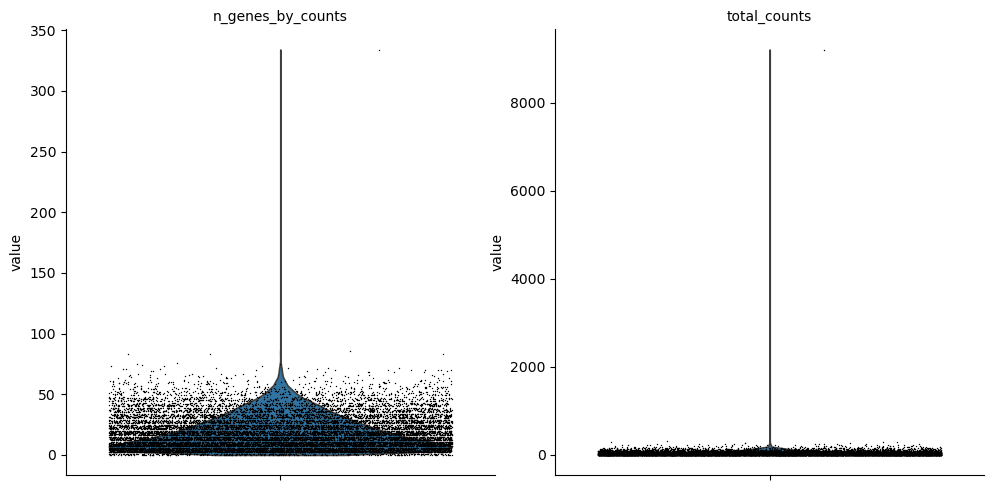

In [20]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

In [21]:
adata = adata[adata.obs['total_counts'] < 2000]

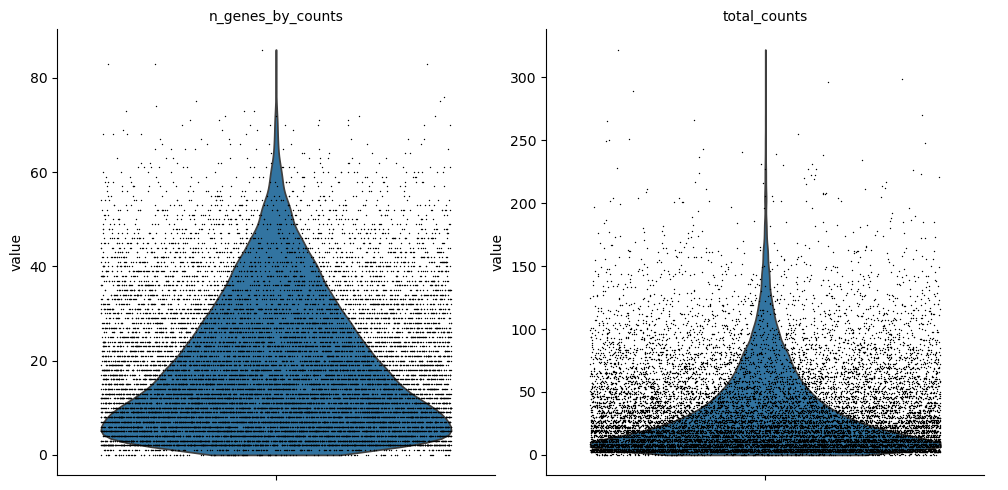

In [22]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

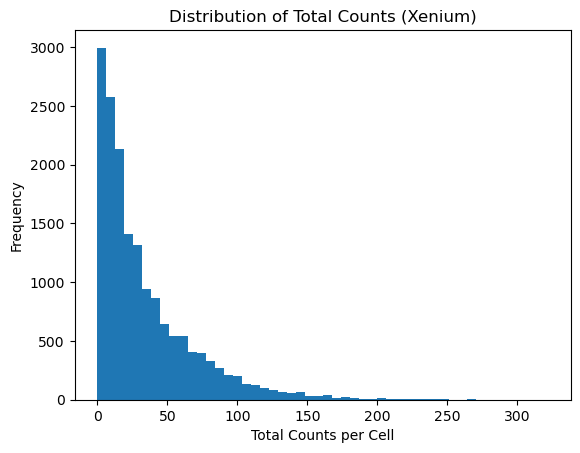

In [23]:
import matplotlib.pyplot as plt

plt.hist(adata.obs['total_counts'], bins=50)
plt.xlabel('Total Counts per Cell')
plt.ylabel('Frequency')
plt.title('Distribution of Total Counts (Xenium)')
plt.show()

normalization

In [24]:
# Normalizing to median total counts
sc.pp.normalize_total(adata,target_sum=None)

# Logarithmize the data
sc.pp.log1p(adata)

/home/l202255179/micromamba/envs/baysor/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/l202255179/micromamba/envs/baysor/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


pca

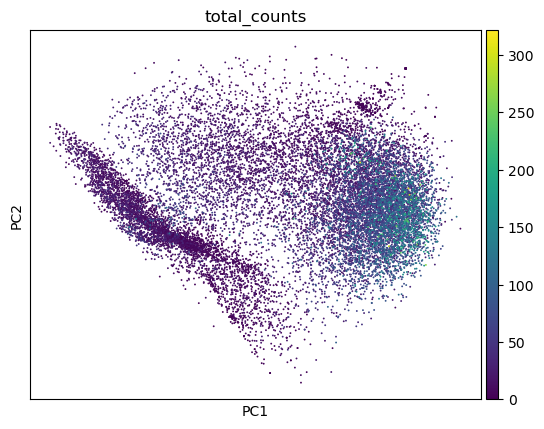

In [25]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca(adata, color="total_counts")

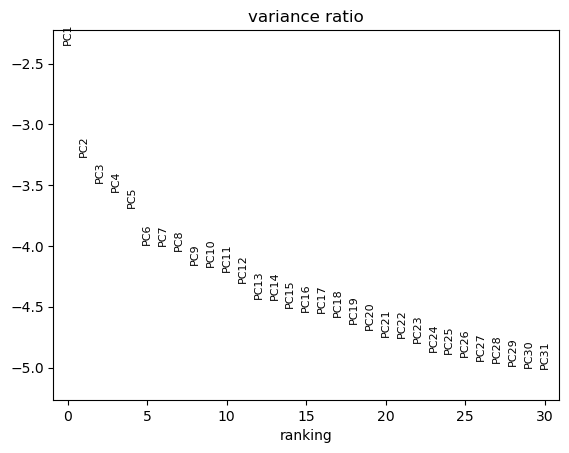

In [26]:
sc.pl.pca_variance_ratio(adata, log=True)

knn & umap

/home/l202255179/micromamba/envs/baysor/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


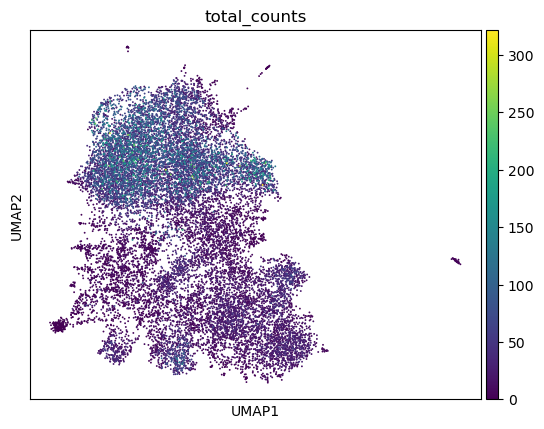

In [27]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color="total_counts",
)

leiden

/tmp/ipykernel_2392223/3698950307.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, n_iterations=2)


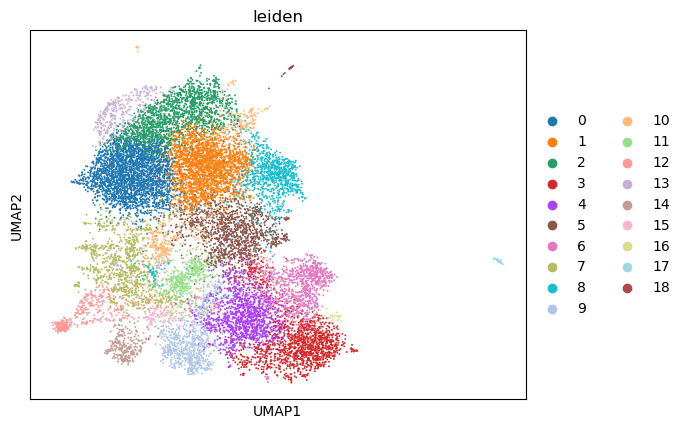

In [28]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, n_iterations=2)
sc.pl.umap(adata, color=["leiden"])

## Celltypist

In [29]:
!pip install celltypist

  Using cached celltypist-1.7.1-py3-none-any.whl.metadata (45 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached charset_normalizer-3.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (35 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached certifi-2025.7.14-py3-none-any.whl.metadata (2.4 kB)
Using cached celltypist-1.7.1-py3-none-any.whl (7.3 MB)
Using cached click-8.2.1-py3-none-any.whl (102 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached requests-2.32.4-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (148 kB)
Using cached idna-3.10-py3-none-any.wh

In [30]:
import celltypist
from celltypist import models

In [31]:
# 로컬에 있는 모델 파일 (.pkl)을 로드
models.models_path=os.getcwd()
model = models.Model.load(model='Human_Colorectal_Cancer.pkl')
model

🔎 No available models. Downloading...
📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 54
📂 Storing models in /bce/groups/pnucolab/analysis/l202255179/kogo/baysor
💾 Downloading model [1/54]: Immune_All_Low.pkl
💾 Downloading model [2/54]: Immune_All_High.pkl
💾 Downloading model [3/54]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/54]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/54]: Adult_Human_MTG.pkl
💾 Downloading model [6/54]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/54]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/54]: Adult_Human_Skin.pkl
💾 Downloading model [9/54]: Adult_Human_Vascular.pkl
💾 Downloading model [10/54]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/54]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/54]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/54]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/54]: Autopsy_COVID19_Lung.pkl
💾 Do

CellTypist model with 36 cell types and 4301 features
    date: 2024-04-26 20:47:44.844844
    details: cell types of colon tissues from patients with colorectal cancer
    source: https://doi.org/10.1038/s41588-020-0636-z
    version: v1
    cell types: CD19+CD20+ B, CD4+ T cells, ..., gamma delta T cells
    features: A1BG, A1CF, ..., ZWINT

In [32]:
predictions = celltypist.annotate(adata, model='Human_Colorectal_Cancer.pkl', majority_voting = True)

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 16635 cells and 422 genes
🔗 Matching reference genes in the model
🧬 351 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [33]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
cell_CRb57179d5a-1,CD19+CD20+ B,0,CD19+CD20+ B
cell_CRb57179d5a-10,CD19+CD20+ B,0,CD19+CD20+ B
cell_CRb57179d5a-100,CMS2,10,CD19+CD20+ B
cell_CRb57179d5a-1000,Myofibroblasts,12,CMS2
cell_CRb57179d5a-10000,CMS2,14,CMS2
...,...,...,...
cell_CRb57179d5a-9995,CMS2,4,CD19+CD20+ B
cell_CRb57179d5a-9996,Mast cells,17,Mast cells
cell_CRb57179d5a-9997,CD19+CD20+ B,127,CMS2
cell_CRb57179d5a-9998,CD19+CD20+ B,77,CMS2


In [34]:
adata

AnnData object with n_obs × n_vars = 16635 × 422
    obs: 'n_genes_by_counts', 'total_counts', 'leiden'
    var: 'feature_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'over_clustering'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [36]:
adata = predictions.to_adata()
adata

AnnData object with n_obs × n_vars = 16635 × 422
    obs: 'n_genes_by_counts', 'total_counts', 'leiden', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    var: 'feature_type', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'over_clustering'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [37]:
adata = predictions.to_adata()
adata.obs['predicted_labels']

cell_CRb57179d5a-1          CD19+CD20+ B
cell_CRb57179d5a-10         CD19+CD20+ B
cell_CRb57179d5a-100                CMS2
cell_CRb57179d5a-1000     Myofibroblasts
cell_CRb57179d5a-10000              CMS2
                               ...      
cell_CRb57179d5a-9995               CMS2
cell_CRb57179d5a-9996         Mast cells
cell_CRb57179d5a-9997       CD19+CD20+ B
cell_CRb57179d5a-9998       CD19+CD20+ B
cell_CRb57179d5a-9999               CMS2
Name: predicted_labels, Length: 16635, dtype: category
Categories (26, object): ['CD19+CD20+ B', 'CD4+ T cells', 'CMS1', 'CMS2', ..., 'Stromal 3', 'T helper 17 cells', 'Tip-like ECs', 'cDC']

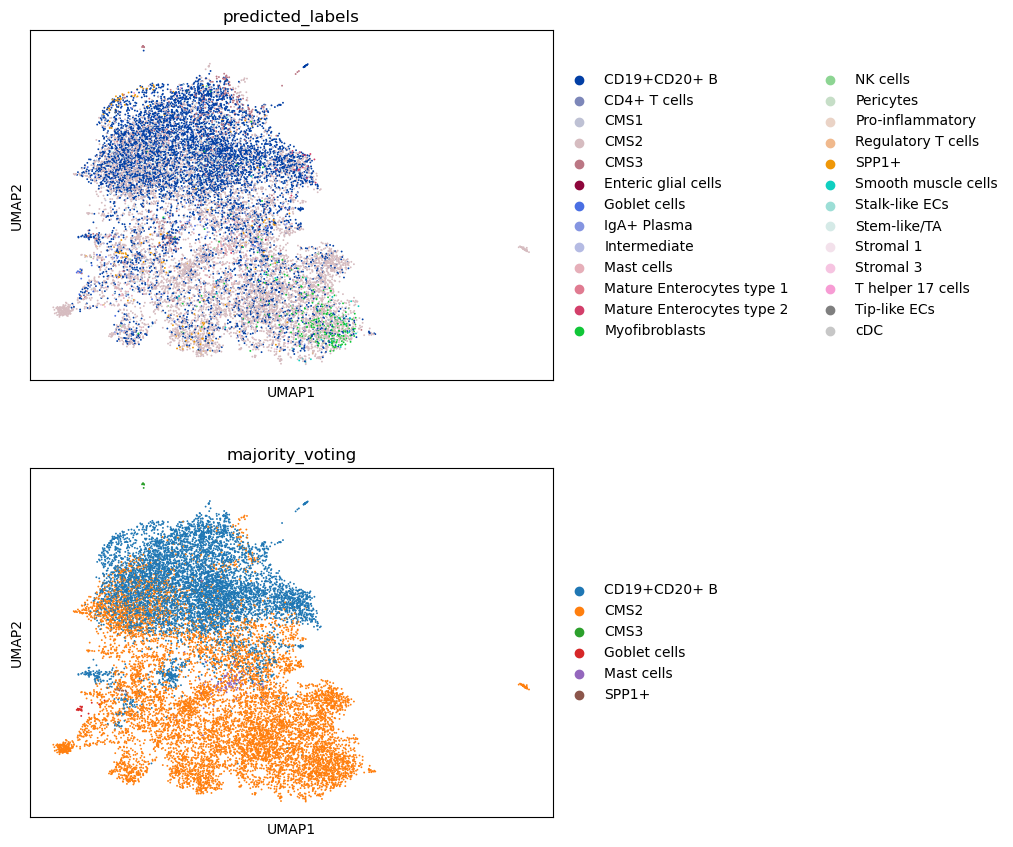

In [38]:
sc.pl.umap(adata, color = ['predicted_labels', 'majority_voting'], ncols=1)

# Xenium dataset to SpatialData

In [39]:
!wget https://public.pnucolab.com/spatial-omics-tutorials/xenium_sdata_cropped.zarr

--2025-07-25 08:06:32--  https://public.pnucolab.com/spatial-omics-tutorials/xenium_sdata_cropped.zarr
Resolving public.pnucolab.com (public.pnucolab.com)... 164.125.255.244
Connecting to public.pnucolab.com (public.pnucolab.com)|164.125.255.244|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: /spatial-omics-tutorials/xenium_sdata_cropped.zarr/ [following]
--2025-07-25 08:06:32--  https://public.pnucolab.com/spatial-omics-tutorials/xenium_sdata_cropped.zarr/
Reusing existing connection to public.pnucolab.com:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘xenium_sdata_cropped.zarr’

xenium_sdata_croppe     [ <=>                ]  30.67K  --.-KB/s    in 0.004s  

2025-07-25 08:06:32 (7.61 MB/s) - ‘xenium_sdata_cropped.zarr’ saved [31406]



In [ ]:
import spatialdata as sd
import spatialdata_plot 
import spatialdata_io

sdata_crop = sd.read_zarr('xenium_sdata_cropped.zarr')

/home/l202255179/micromamba/envs/pkogo/lib/python3.12/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_circles` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/l202255179/micromamba/envs/pkogo/lib/python3.12/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


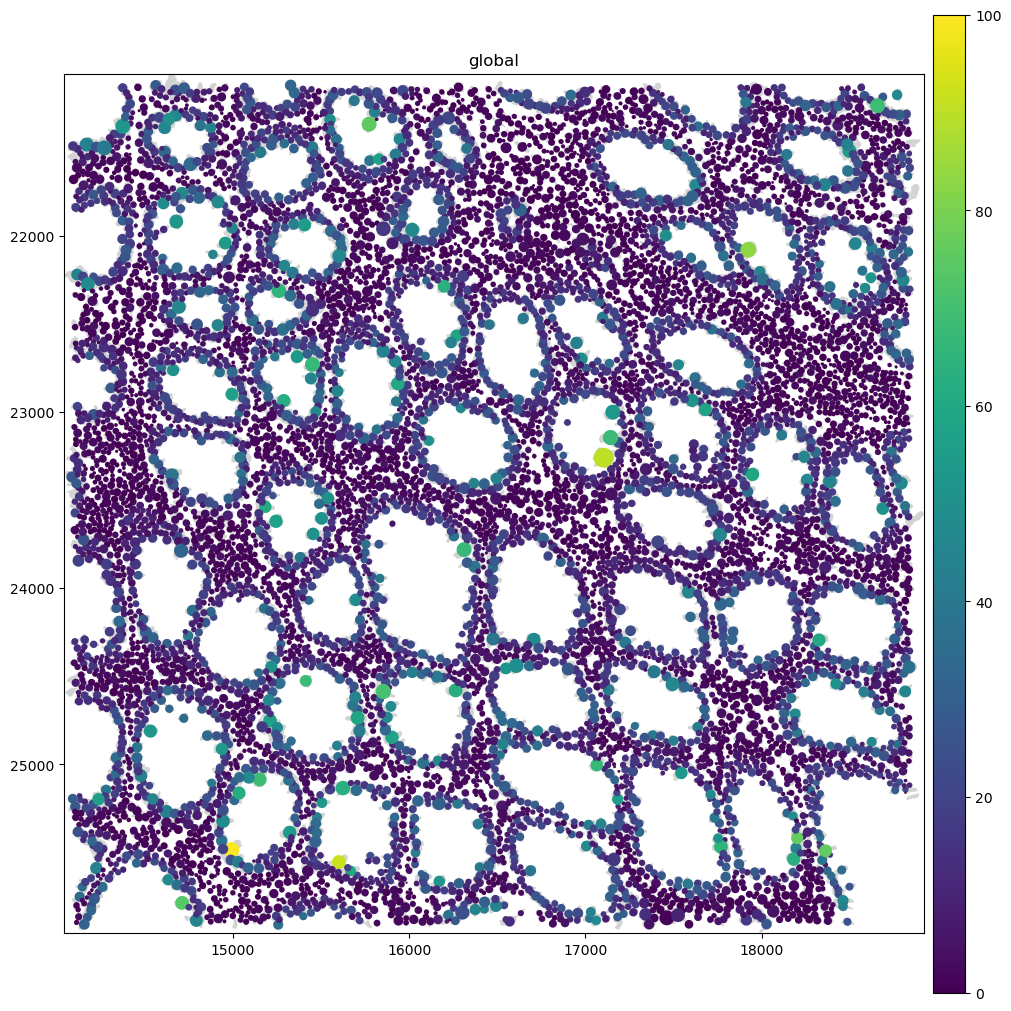

In [7]:
sdata_crop.pl.render_shapes(color="PIGR").pl.show(figsize=(10, 10))

INFO     Rasterizing image for faster rendering.                                                                   


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.125428681276432].


INFO     Rasterizing image for faster rendering.                                                                   


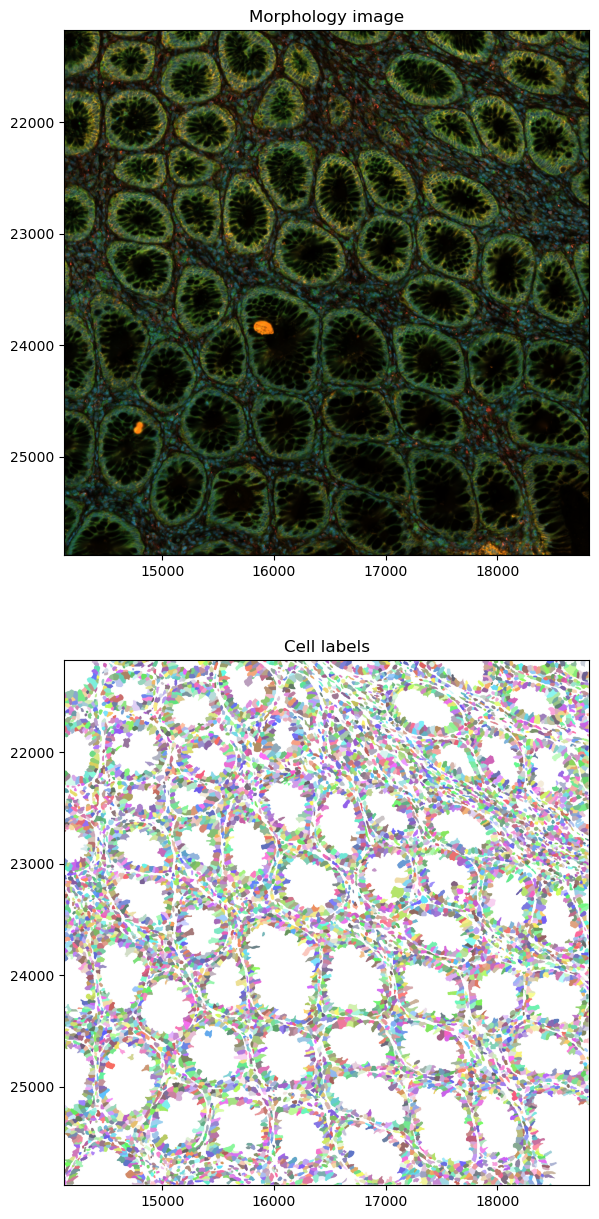

In [8]:
import matplotlib.pyplot as plt

axes = plt.subplots(2, 1, figsize=(25, 15))[1].flatten()

sdata_crop.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="Morphology image", coordinate_systems="global"
)
sdata_crop.pl.render_labels("cell_labels").pl.show(ax=axes[1], title="Cell labels", coordinate_systems="global")


In [9]:
import json
import geopandas as gpd
from shapely.geometry import shape

# 1. JSON 파일 읽기 (파일 경로를 적절히 수정)
with open("segmentation_polygons_2d.json", "r") as f:
    data = json.load(f)

# 2. data['features']에서 각 feature의 id와 geometry를 추출하여 레코드 리스트 생성
records = []
for feat in data["features"]:
    cell_id = feat.get("id")
    # shapely의 shape() 함수를 이용하여 geometry 객체 생성
    geom = shape(feat.get("geometry"))
    records.append({"id": cell_id, "geometry": geom})

# 3. GeoDataFrame 생성
gdf = gpd.GeoDataFrame(records)

gdf = gdf.set_index('id')
gdf.index.name = None  # 인덱스 이름 제거

# 결과 확인
print(type(gdf))  # <class 'geopandas.geodataframe.GeoDataFrame'>
print(gdf.head())

<class 'geopandas.geodataframe.GeoDataFrame'>
                                                            geometry
CR1ba760eab-4673   POLYGON ((3032.832 5185.059, 3032.403 5188.256...
CR1ba760eab-15520  POLYGON ((3831.691 5267.237, 3829.762 5268.924...
CR1ba760eab-6534   POLYGON ((3649.925 4705.282, 3648.337 4701.892...
CR1ba760eab-15895  POLYGON ((3958.479 5213.175, 3960.328 5214.526...
CR1ba760eab-4103   POLYGON ((3079.768 5097.403, 3079.536 5096, 30...


In [10]:
from shapely.affinity import scale

# 각 geometry에 대해 x, y 방향으로 factor만큼 스케일링합니다.
gdf["geometry"] = gdf["geometry"].apply(lambda geom: scale(geom, xfact=(1/pixel_size), yfact=(1/pixel_size), origin=(0, 0)))


In [11]:
from spatialdata.models import ShapesModel

sdata_crop.shapes['cell_boundaries_baysor'] = ShapesModel.parse(gdf)

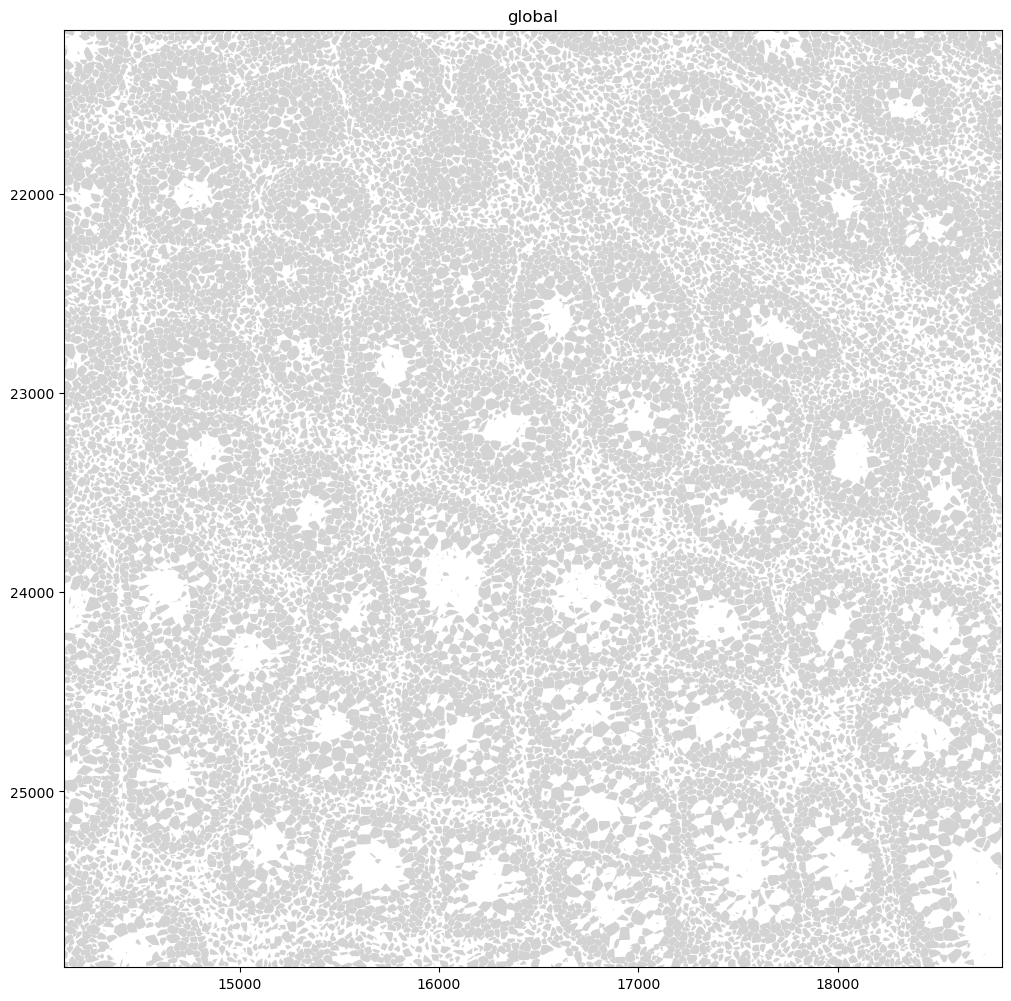

In [12]:
sdata_crop.pl.render_shapes("cell_boundaries_baysor", method='matplotlib').pl.show(coordinate_systems="global", figsize=(10, 10))


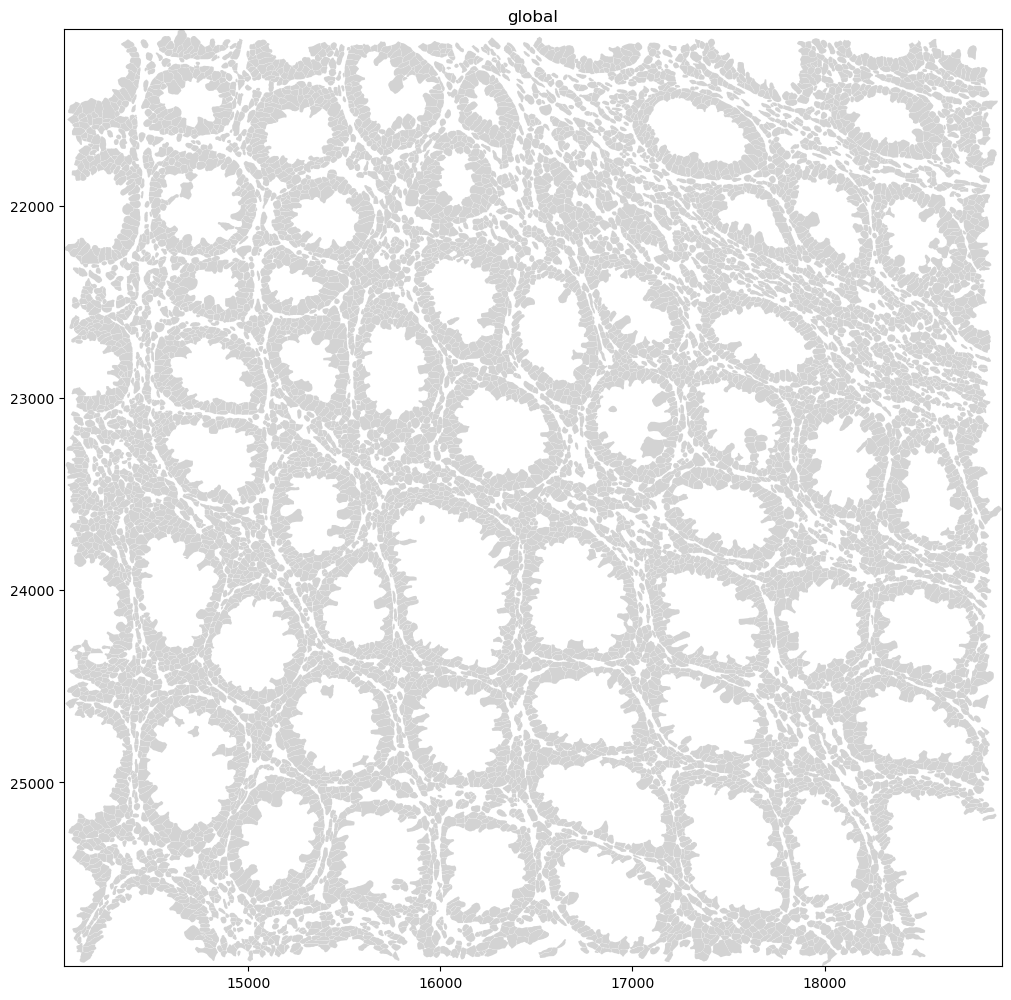

In [13]:
sdata_crop.pl.render_shapes("cell_boundaries", method='matplotlib').pl.show(coordinate_systems="global", figsize=(10, 10))
